# SOLUTION: Compute the latitudinally weighted mean over space and time for the NUTS regions

Provide the additional arguments to the `ekt.spatial.reduce` method to compute the
latitudinally weighted mean, over space and time, for the nuts_regions.

For me details and hints, see the [Reducing data-cubes using geometry objects tutorial](https://earthkit-transforms.readthedocs.io/en/latest/tutorials/spatial/02-era5-reduce-data-over-geometries.html).

In [1]:
from earthkit import data as ekd
from earthkit import geo as ekg
from earthkit import plots as ekp
from earthkit import transforms as ekt
from earthkit.transforms._tools import earthkit_remote_test_data_file

## Load some test data

In this example we will use hourly ERA5 2m temperature data on a 0.5x0.5 spatial grid for the year 2015 as
our physical data; and we will use the NUTS regions geometries which are available in `earthkit.geo`.

In [2]:
# NUTS regions
nuts_data = ekg.gisco.nuts_regions(level=0).to_geopandas()
nuts_data.head()

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,NAME_ENGL,NAME_FREN,ISO3_CODE,SVRG_UN,CAPT,EU_STAT,EFTA_STAT,CC_STAT,NAME_GERM,geometry
0,BA,0,BA,Bosna I Hercegovina,Bosna I Hercegovina,0.0,NaN,NaN,Bosnia and Herzegovina,Bosnie-et-Herzégovine,BIH,UN Member State,Sarajevo,F,F,T,Bosnien und Herzegowina,"MULTIPOLYGON (((16.92382 45.26542, 17.14119 45..."
1,BE,0,BE,Belgique/België,Belgique/België,NaN,NaN,NaN,Belgium,Belgique,BEL,UN Member State,Brussels,T,F,F,Belgien,"POLYGON ((4.82637 51.48207, 4.84186 51.42493, ..."
2,BG,0,BG,Bulgaria,България,NaN,NaN,NaN,Bulgaria,Bulgarie,BGR,UN Member State,Sofia,T,F,F,Bulgarien,"POLYGON ((22.88233 43.83546, 22.99717 43.80787..."
3,CH,0,CH,Schweiz/Suisse/Svizzera,Schweiz/Suisse/Svizzera,NaN,NaN,NaN,Switzerland,Suisse,CHE,UN Member State,Bern,F,T,F,Schweiz,"POLYGON ((8.70462 47.75557, 8.72798 47.69268, ..."
4,CY,0,CY,Kýpros,Κύπρος,NaN,NaN,NaN,Cyprus,Chypre,CYP,UN Member State,Nicosia,T,F,F,Zypern,"POLYGON ((32.25443 35.06555, 32.42709 35.08197..."


In [3]:
remote_era5_file = earthkit_remote_test_data_file("era5_temperature_europe_20150101.grib")
era5_data = ekd.from_source("url", remote_era5_file)
# Convert to xarray, we keep all time steps for the challenge
era5_xr = era5_data.to_xarray(time_dims=["valid_time"]).rename({"2t": "t2m"})
era5_xr

<xarray.Dataset> Size: 11MB
Dimensions:     (valid_time: 24, latitude: 201, longitude: 281)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 192B 2015-01-01 ... 2015-01-01T23...
  * latitude    (latitude) float64 2kB 80.0 79.75 79.5 79.25 ... 30.5 30.25 30.0
  * longitude   (longitude) float64 2kB -10.0 -9.75 -9.5 ... 59.5 59.75 60.0
Data variables:
    t2m         (valid_time, latitude, longitude) float64 11MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

## Reduce data

In [4]:
reduced_data = ekt.spatial.reduce(
    era5_xr,
    nuts_data,
    mask_dim="NAME_ENGL",
    how="mean",  # Default value
    extra_reduce_dims=["valid_time"],  # Reduce also in the time dimension
    weights="latitude",  # Weight the mean with latitude
)

# Add the reduced data back to the original GeoDataFrame for plotting
nuts_data = nuts_data.assign(t2m=reduced_data.t2m)

Below we compare the unweighted and weighted means, we do this by adding the difference in t2m to the geopandas and plotting using the `geo.choropleth` method in `earthkit.plots`.

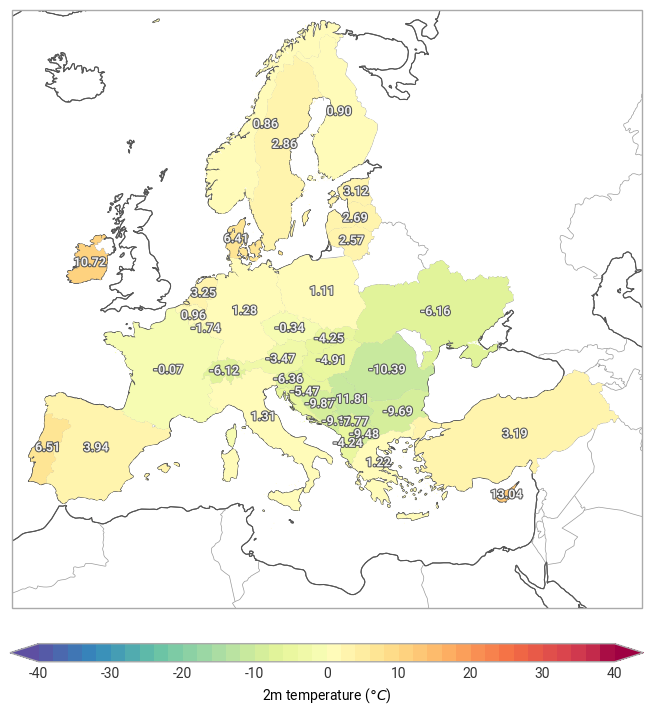

In [5]:
fig = ekp.geo.choropleth(
    nuts_data,
    z="t2m",
    domain="Europe",
    metadata={"units": "K", "long_name": "2m temperature"},
    units="celsius",
    labels="{t2m:0.2f}",
)
fig.coastlines()
fig.borders()
fig.show()